<h2>Préambule</h2>
Le championnat de France de football, appelé <b>Ligue 1</b>, est le championnat professionnel de football de plus haut niveau organisé par la Fédération française de football.

<h2>Fichier mis à disposition</h2>
Le fichier 'season-1819.csv' recense tous les matchs disputés sur la saison 2018-2019. Ce jeu de données provient du site <b>pkgstore.datahub.io</b>.

<h3>Étape 1 : Nombre de buts inscrits par match</h3>

<b>1. Lecture et traitement du jeu de données</b>

In [1]:
import pandas as pd

data = pd.read_csv('season-1819.csv')

data.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA
0,F1,10/08/2018,Marseille,Toulouse,4,0,H,1,0,H,...,2.11,18,-1.25,2.05,1.98,1.91,1.87,1.48,4.53,7.70
1,F1,11/08/2018,Angers,Nimes,3,4,A,1,1,D,...,1.66,20,-0.25,1.99,1.95,1.94,1.90,2.36,3.15,3.51
2,F1,11/08/2018,Lille,Rennes,3,1,H,1,1,D,...,1.64,20,0.00,1.82,1.77,2.15,2.09,2.81,3.31,2.72
3,F1,11/08/2018,Montpellier,Dijon,1,2,A,1,0,H,...,1.71,20,-1.00,2.45,2.32,1.67,1.61,1.74,3.68,5.60
4,F1,11/08/2018,Nantes,Monaco,1,3,A,0,0,D,...,1.74,20,0.25,1.90,1.85,2.06,2.01,2.59,3.29,2.98


On sélectionne et on renomme les colonnes sur lesquelles nous allons travailler. On obtient :

<ul>
    <li><b>Date :</b> date du match</li>
    <li><b>DOM :</b> nom de l'équipe jouant à <b>domicile</b></li>
    <li><b>EXT :</b> nom de l'équipe jouant à <b>l’extérieur</b></li>
    <li><b>BDOM :</b> nombre de buts inscrits par l'équipe jouant à <b>domicile</b></li>
    <li><b>BEXT :</b> nombre de buts inscrits par l'équipe jouant à <b>l’extérieur</b></li>
</ul>

In [2]:
col = ['Date','HomeTeam','AwayTeam','FTHG','FTAG']
data = data[col]

data.rename(columns={'HomeTeam':'DOM','AwayTeam':'EXT','FTHG':'BDOM','FTAG':'BEXT'}, inplace=True)

data.head()

,Date,DOM,EXT,BDOM,BEXT
0,10/08/2018,Marseille,Toulouse,4,0
1,11/08/2018,Angers,Nimes,3,4
2,11/08/2018,Lille,Rennes,3,1
3,11/08/2018,Montpellier,Dijon,1,2
4,11/08/2018,Nantes,Monaco,1,3


In [3]:
# Nombre de matchs joués au cours de la saison 2018-2019
len(data)

380

<b>2. Nombre de buts inscrits à domicile</b>

In [4]:
# Nombre total de buts inscrits à domicile au cours de la saison
buts_dom_tot = data['BDOM'].sum()
buts_dom_tot

np.int64(559)

In [5]:
nb_matchs_buts = (
    data['BDOM']
    .value_counts()
    .sort_index()
    .reset_index()
)

nb_matchs_buts.columns = ['nb_buts_dom', 'nb_matchs']

nb_matchs_buts

,nb_buts_dom,nb_matchs
0,0,88
1,1,127
2,2,99
3,3,43
4,4,14
5,5,8
6,9,1


<ul>
    <li>Il y a 88 matchs où l'équipe jouant à domicile n'a inscrit aucun but.</li>
    <li>Il y a 127 matchs où l'équipe à domicile a inscrit un seul but.</li>
</ul>

<b>Diagramme en barres de la distribution du nombre de buts par match inscrits par les équipes à domicile</b>

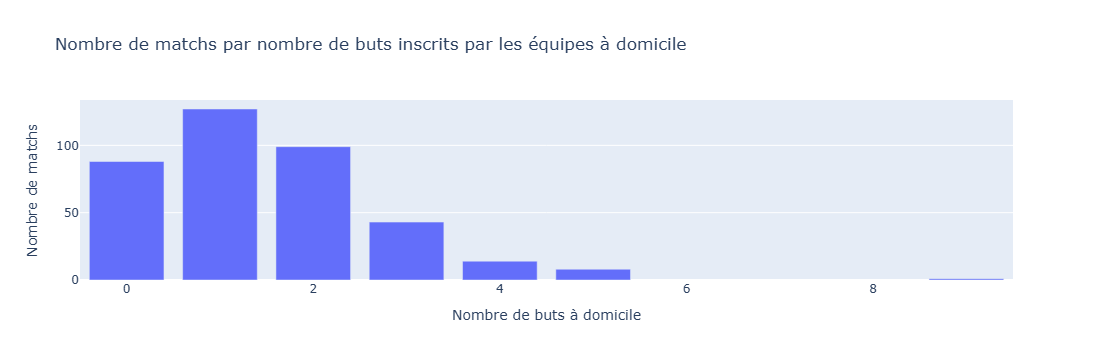

In [6]:
import plotly.express as px

fig = px.bar(
    nb_matchs_buts,
    x='nb_buts_dom',
    y='nb_matchs',
    title='Nombre de matchs par nombre de buts inscrits par les équipes à domicile'
)

fig.update_layout(
    xaxis_title='Nombre de buts à domicile',
    yaxis_title='Nombre de matchs'
)

fig.show()

<b>3. Modélisation du nombre de buts inscrits à domicile par match</b>

<b>Choix d'un premier modèle :</b>
<ul>
    <li>On découpe la durée du match en 45 intervalles de 2 minutes chacun.</li>
    <li><b>On suppose que :</b>
        <ul>
            <li>chaque intervalle est indépendant des autres</li>
            <li>l'apparition d'un but dans un intervalle est indépendante de celle dans les autres intervalles</li>
        </ul>
    </li>
    <li>On note X la variable aléatoire qui, pour un match donné, compte le nombre de buts inscrits par l'équipe jouant à domicile.</li>
</ul>

In [7]:
# Nombre moyen de buts inscrits à domicile par match
moyenne_dom = data['BDOM'].mean()
moyenne_dom

np.float64(1.4710526315789474)

En moyenne, une équipe jouant à domicile marque 1,47 but par match. Ici, l’espérance de X vaut E[X] = 1,47.

Lors d'un match, la variable aléatoire qui compte le nombre de buts inscrits par une équipe à domicile suit une <b>loi binomiale</b> de paramètres n = 45 et p, où p est la probabilité pour l'équipe à domicile d'inscrire un but durant un intervalle de 2 minutes.

Puisque E[X] = n × p, on a alors p = E[X] / n.

In [8]:
p_dom = moyenne_dom/45 
p_dom

np.float64(0.032690058479532165)

<b>4. Pertinence du modèle</b>

In [9]:
from scipy.stats import binom

# Définition de X ~ Binomiale(n=45, p=p_dom)
X = binom(n=45, p=p_dom)

# Effectifs théoriques sur 380 matchs
E = [380 * X.pmf(k) for k in range(7)]  # on écarte les valeurs rares (≥ 7 buts)

E

[np.float64(85.16044125864549),
 np.float64(129.50915300533373),
 np.float64(96.2882270515444),
 np.float64(46.64127750514823),
 np.float64(16.550449085089646),
 np.float64(4.586418506513136),
 np.float64(1.0333143683940296)]

<b>Comparaison à l'aide du diagramme précédent</b>

In [10]:
nb_matchs_buts['predictions'] = E

In [11]:
nb_matchs_buts

,nb_buts_dom,nb_matchs,predictions
0,0,88,85.160441
1,1,127,129.509153
2,2,99,96.288227
3,3,43,46.641278
4,4,14,16.550449
5,5,8,4.586419
6,9,1,1.033314


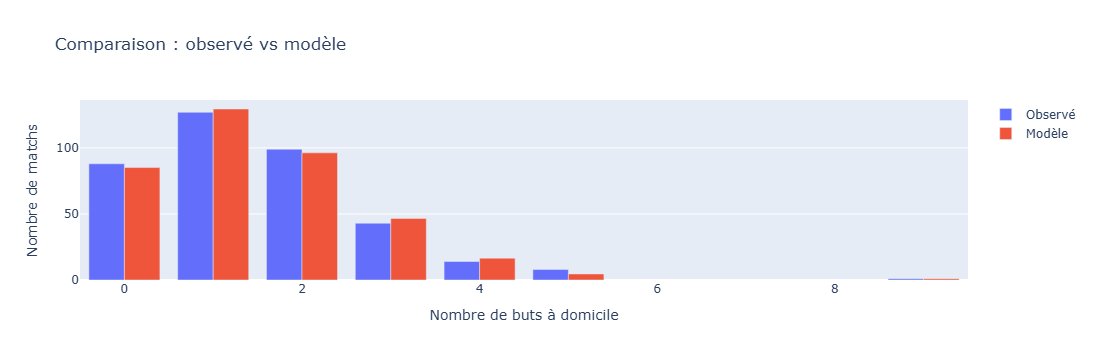

In [12]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_bar(
    x=nb_matchs_buts['nb_buts_dom'],
    y=nb_matchs_buts['nb_matchs'],
    name='Observé'
)

fig.add_bar(
    x=nb_matchs_buts['nb_buts_dom'],
    y=nb_matchs_buts['predictions'],
    name='Modèle'
)

fig.update_layout(
    barmode='group',
    title='Comparaison : observé vs modèle',
    xaxis_title='Nombre de buts à domicile',
    yaxis_title='Nombre de matchs'
)

fig.show()

Le modèle proposé semble acceptable.

<b>5. Loi du nombre de buts inscrits par l’équipe à l’extérieur</b>

On note Y la variable aléatoire qui compte le nombre de buts inscrits par l’équipe à l’extérieur.

In [13]:
# Nombre moyen de buts inscrits à l'extérieur par match
moyenne_ext = data['BEXT'].mean()
moyenne_ext

np.float64(1.0868421052631578)

<ul>
    <li>Ici, E[Y] = 1,09.</li>
    <li>Y suit une <b>loi binomiale</b> de paramètres n = 45 et p, où p est la probabilité pour l'équipe à l’extérieur d'inscrire un but durant un intervalle de 2 minutes.</li>
    <li>Puisque E[Y] = n × p, on a alors p = E[Y] / n.</li>
</ul>

In [14]:
p_ext = moyenne_ext / 45
p_ext

np.float64(0.02415204678362573)

In [15]:
# Définition de Y ~ Binomiale(n=45, p=p_ext)
Y = binom(n=45, p=p_ext)

# Effectifs théoriques sur 380 matchs
E_ext = [380 * Y.pmf(k) for k in range(6)]

E_ext

[np.float64(126.46798425567756),
 np.float64(140.8526090604522),
 np.float64(76.69364211201948),
 np.float64(27.206855441708186),
 np.float64(7.070325919755954),
 np.float64(1.434911353739168)]

In [16]:
nb_matchs_buts_ext = (
    data['BEXT']
    .value_counts()
    .sort_index()
    .reset_index()
)

nb_matchs_buts_ext.columns = ['nb_buts_ext', 'nb_matchs']

nb_matchs_buts_ext

,nb_buts_ext,nb_matchs
0,0,135
1,1,135
2,2,68
3,3,29
4,4,10
5,5,3


In [17]:
nb_matchs_buts_ext['predictions'] = E_ext
nb_matchs_buts_ext

,nb_buts_ext,nb_matchs,predictions
0,0,135,126.467984
1,1,135,140.852609
2,2,68,76.693642
3,3,29,27.206855
4,4,10,7.070326
5,5,3,1.434911


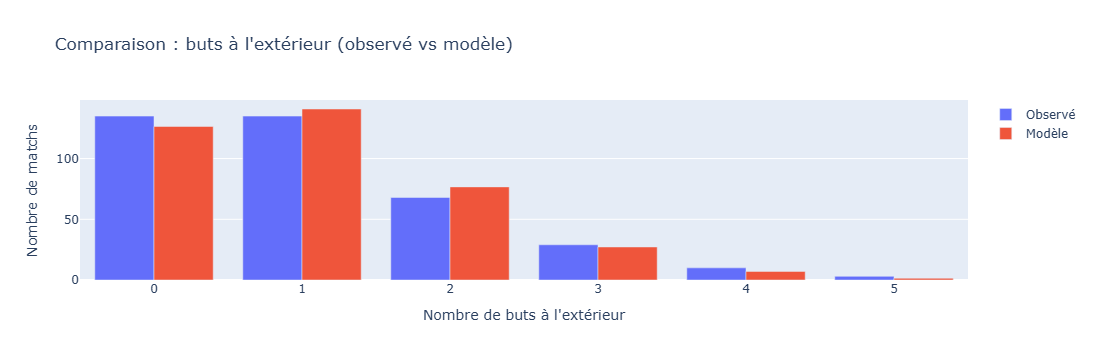

In [18]:
fig = go.Figure()

fig.add_bar(
    x=nb_matchs_buts_ext['nb_buts_ext'],
    y=nb_matchs_buts_ext['nb_matchs'],
    name='Observé'
)

fig.add_bar(
    x=nb_matchs_buts_ext['nb_buts_ext'],
    y=nb_matchs_buts_ext['predictions'],
    name='Modèle'
)

fig.update_layout(
    barmode='group',
    title="Comparaison : buts à l'extérieur (observé vs modèle)",
    xaxis_title="Nombre de buts à l'extérieur",
    yaxis_title="Nombre de matchs"
)

fig.show()

Le modèle proposé semble acceptable.

<h3>Étape 2 : Buts inscrits durant le match Marseille - Toulouse</h3>

<b>Marseille</b> affronte à domicile <b>Toulouse</b>. À partir des statistiques des deux équipes, <b>on modélise</b> :
<ul>
    <li>le nombre de buts inscrits par <b>Marseille</b> par une variable aléatoire X</li>
    <li>le nombre de buts inscrits par <b>Toulouse</b> par une variable aléatoire Y</li>
</ul>
<b>On suppose que :</b>
<ul>
    <li>X suit une loi binomiale de paramètres n = 45 et p<sub>DOM</sub>.</li>
    <li>Y suit une loi binomiale de paramètres n = 45 et p<sub>EXT</sub>.</li>
</ul>

<h4>Objectif :</h4>
Estimer p<sub>DOM</sub> et p<sub>EXT</sub> à partir des moyennes de buts par match :
<ul>
    <li>inscrits par <b>Marseille</b> et <b>Toulouse</b></li>
    <li>concédés par <b>Marseille</b> et <b>Toulouse</b></li>
</ul>

<b>1. Performances d'attaque et de défense de Marseille à domicile</b>

<ul>
    <li>La performance d'attaque de Marseille à domicile est : <br>
    nombre moyen de buts inscrits à domicile / nombre moyen de buts inscrits en Ligue 1 à domicile sur la saison</li>
    <li>La performance défensive de Marseille à domicile est : <br>
    nombre moyen de buts concédés à domicile / nombre moyen de buts concédés en Ligue 1 à domicile sur la saison</li>
</ul>

In [19]:
moyenne_marseille = (
    data[data['DOM'] == 'Marseille'][['BDOM', 'BEXT']]
    .mean()
)

moyenne_marseille

BDOM    1.631579
BEXT    0.894737
dtype: float64

En moyenne, lors d’un match à domicile, Marseille inscrit 1,63 but et concède 0,89 but.

In [20]:
# Performance d'attaque de Marseille à domicile :
attaque_marseille_dom = moyenne_marseille['BDOM'] / moyenne_dom

attaque_marseille_dom 

np.float64(1.10912343470483)

En moyenne, par rapport aux équipes jouant à domicile, Marseille inscrit 11 % de buts en plus.

In [21]:
# Performance défensive de Marseille à domicile :
defense_marseille_dom = moyenne_marseille['BEXT']/ moyenne_ext

defense_marseille_dom 

np.float64(0.8232445520581114)

En moyenne, par rapport aux équipes jouant à domicile, Marseille encaisse 18 % de buts en moins.

<b>2. Performances d'attaque et de défense de Toulouse à l'extérieur</b>

<ul>
    <li>La performance d'attaque de Toulouse à l'extérieur est : <br>
    nombre moyen de buts inscrits à l’extérieur / nombre moyen de buts inscrits en Ligue 1 à l’extérieur sur la saison</li>
    <li>La performance défensive de Toulouse à l'extérieur est : <br>
    nombre moyen de buts concédés à l’extérieur / nombre moyen de buts concédés en Ligue 1 à l’extérieur sur la saison</li>
</ul>

In [22]:
moyenne_toulouse = (
    data[data['EXT'] == 'Toulouse'][['BDOM', 'BEXT']]
    .mean()
)

moyenne_toulouse

BDOM    1.631579
BEXT    0.789474
dtype: float64

En moyenne, lorsque Toulouse joue à l’extérieur, elle encaisse 1,63 but et inscrit 0,79 but.

In [23]:
# Attaque
attaque_toulouse_ext = moyenne_toulouse['BEXT'] / moyenne_ext

attaque_toulouse_ext

np.float64(0.7263922518159807)

In [24]:
# Defense
defense_toulouse_ext = moyenne_toulouse['BDOM'] / moyenne_dom

defense_toulouse_ext

np.float64(1.10912343470483)

Par rapport à la moyenne, Toulouse est moins performante en attaque et en défense à l’extérieur.

<b>3. Estimation des espérances de X et de Y pour le match Marseille - Toulouse</b>

Durant le match <b>Marseille - Toulouse</b>, on estime que :
<ul>
    <li>l'espérance de X est : <br>E[X] = attaque_marseille_dom × defense_toulouse_ext × moyenne_dom</li>
    <li>l'espérance de Y est : <br>E[Y] = attaque_toulouse_ext × defense_marseille_dom × moyenne_ext</li>
</ul>
Ces calculs sont utilisés par les bookmakers et peuvent être affinés par des modèles statistiques plus performants.

In [25]:
# Espérance de X, la variable aléatoire modélisant le nombre de buts inscrits par Marseille à domicile contre Toulouse
E_X = attaque_marseille_dom * defense_toulouse_ext * moyenne_dom
E_X

np.float64(1.809622446097354)

In [26]:
# Espérance de Y, la variable aléatoire modélisant le nombre de buts inscrits par Toulouse à l'extérieur contre Marseille
E_Y = attaque_toulouse_ext * defense_marseille_dom * moyenne_ext
E_Y

np.float64(0.6499299095195616)

<b>Automatisation</b>

In [27]:
def Esp(e1, e2):
    # Moyennes à domicile pour e1
    moyenne_e1 = data[data['DOM'] == e1][['BDOM', 'BEXT']].mean()
    
    # Moyennes à l'extérieur pour e2
    moyenne_e2 = data[data['EXT'] == e2][['BDOM', 'BEXT']].mean()
    
    # Performances
    attaque_e1 = moyenne_e1['BDOM'] / moyenne_dom
    defense_e1 = moyenne_e1['BEXT'] / moyenne_ext
    
    attaque_e2 = moyenne_e2['BEXT'] / moyenne_ext
    defense_e2 = moyenne_e2['BDOM'] / moyenne_dom
    
    # Espérances
    EX = attaque_e1 * defense_e2 * moyenne_dom
    EY = attaque_e2 * defense_e1 * moyenne_ext

    return EX, EY

In [28]:
Esp('Marseille', 'Toulouse')

(np.float64(1.809622446097354), np.float64(0.6499299095195616))

<b>4. Probabilité d’obtenir un match nul entre ces deux équipes</b>

Il s'agit de calculer P(X = Y) = P(X = Y = 0) + ... + P(X = Y = 6).<br>
Par indépendance de X et Y, on a :
P(X = Y) = P(X = 0) × P(Y = 0) + ... + P(X = 6) × P(Y = 6).

In [29]:
m1, m2 = Esp('Marseille', 'Toulouse')

X = binom(n=45, p=m1 / 45)
Y = binom(n=45, p=m2 / 45)

s = sum(X.pmf(i) * Y.pmf(i) for i in range(7))

s

np.float64(0.21820548533571843)

<h3>Étape 3 : Pertinence du modèle par simulation</h3>

<b>1. Espérance du nombre de buts par équipe pour chacun des 380 matchs de la saison</b>

In [30]:
data.head()

,Date,DOM,EXT,BDOM,BEXT
0,10/08/2018,Marseille,Toulouse,4,0
1,11/08/2018,Angers,Nimes,3,4
2,11/08/2018,Lille,Rennes,3,1
3,11/08/2018,Montpellier,Dijon,1,2
4,11/08/2018,Nantes,Monaco,1,3


In [31]:
for idx in data.index:
    e1 = data.loc[idx, 'DOM']
    e2 = data.loc[idx, 'EXT']
    data.loc[idx, 'EX'], data.loc[idx, 'EY'] = Esp(e1, e2)

data.head()

,Date,DOM,EXT,BDOM,BEXT,EX,EY
0,10/08/2018,Marseille,Toulouse,4,0,1.809622,0.649930
1,11/08/2018,Angers,Nimes,3,4,1.717352,1.513954
2,11/08/2018,Lille,Rennes,3,1,2.689012,0.785013
3,11/08/2018,Montpellier,Dijon,1,2,1.809622,0.662674
4,11/08/2018,Nantes,Monaco,1,3,1.845401,1.162228


<b>2. Comptage des points obtenus par chaque équipe</b>

Durant une saison, on considère chaque match joué et on attribue les points suivants :
<ul>
    <li><b>Victoire :</b> + 3 points pour l'équipe gagnante</li>
    <li><b>Match nul :</b> + 1 point pour chaque équipe</li>
</ul>

In [32]:
P_Off = {equipe : 0 for equipe in set(data['DOM'])}
P_Off

{'Rennes': 0,
 'Nantes': 0,
 'Toulouse': 0,
 'Montpellier': 0,
 'Lille': 0,
 'Reims': 0,
 'Paris SG': 0,
 'Nimes': 0,
 'Amiens': 0,
 'Strasbourg': 0,
 'Marseille': 0,
 'Nice': 0,
 'Angers': 0,
 'Bordeaux': 0,
 'Caen': 0,
 'St Etienne': 0,
 'Dijon': 0,
 'Monaco': 0,
 'Guingamp': 0,
 'Lyon': 0}

In [33]:
for e1, e2, x, y in zip(data['DOM'], data['EXT'], data['BDOM'], data['BEXT']):
    if x > y:
        P_Off[e1] += 3
    elif x == y:
        P_Off[e1] += 1
        P_Off[e2] += 1
    else:
        P_Off[e2] += 3

P_Off

{'Rennes': 52,
 'Nantes': 48,
 'Toulouse': 38,
 'Montpellier': 59,
 'Lille': 75,
 'Reims': 55,
 'Paris SG': 91,
 'Nimes': 53,
 'Amiens': 38,
 'Strasbourg': 49,
 'Marseille': 61,
 'Nice': 56,
 'Angers': 46,
 'Bordeaux': 41,
 'Caen': 33,
 'St Etienne': 66,
 'Dijon': 34,
 'Monaco': 36,
 'Guingamp': 27,
 'Lyon': 72}

<b>3. Simulation du nombre de buts inscrits par équipe pour un match donné</b>

<ul>
    <li>Soit X une variable aléatoire qui compte le nombre de buts inscrits par une équipe lors d’un match donné.</li>
    <li>X suit une loi binomiale de paramètres n = 45 et p.</li>
</ul>

In [34]:
import random

def nb_buts(EX):
    X = 0
    p = EX / 45
    for _ in range(45):
        if random.random() < p:
            X += 1
    return X

<h4>Objectif :</h4>
Si la modélisation de chaque rencontre est satisfaisante, alors, sur plusieurs simulations de cette saison, on doit obtenir un classement des équipes proche de celui réellement observé.<br>
<b>Vérifions si c’est bien le cas.</b>

<b>4. Simulation de 2000 saisons 2018-2019</b>

In [35]:
def simulation(n):
    
    # Initialisation
    equipes = set(data['DOM']) | set(data['EXT'])
    P = {team: 0 for team in equipes}
    
    # Simulation
    for _ in range(n):
        for e1, e2, EX, EY in zip(data['DOM'], data['EXT'], data['EX'], data['EY']):

            x = nb_buts(EX)
            y = nb_buts(EY)

            if x > y:
                P[e1] += 3
            elif x == y:
                P[e1] += 1
                P[e2] += 1
            else:
                P[e2] += 3

    # Moyenne
    return {team: P[team] / n for team in P}

In [36]:
P_Sim = simulation(2000)
P_Sim

{'Rennes': 56.478,
 'Nantes': 51.536,
 'Toulouse': 37.8695,
 'Montpellier': 60.547,
 'Lille': 76.1025,
 'Reims': 50.4555,
 'Paris SG': 90.184,
 'Nimes': 54.4795,
 'Amiens': 37.5995,
 'Strasbourg': 60.2185,
 'Marseille': 60.057,
 'Nice': 47.491,
 'Angers': 49.5255,
 'Bordeaux': 44.954,
 'Caen': 34.3655,
 'St Etienne': 65.974,
 'Dijon': 32.896,
 'Monaco': 39.684,
 'Guingamp': 27.5515,
 'Lyon': 68.756}

<b>5. Classement des équipes et évaluation de la pertinence du modèle</b>

In [37]:
equipes = sorted(set(data['DOM']) | set(data['EXT']))

df = pd.DataFrame({'Equipe': equipes})

# Remplissage
df['Points_Off'] = df['Equipe'].map(P_Off)
df['Points_Sim'] = df['Equipe'].map(P_Sim)

# Rangs
df['Rangs_Off'] = df['Points_Off'].rank(ascending=False, method='min').astype(int)
df['Rangs_Sim'] = df['Points_Sim'].rank(ascending=False, method='min').astype(int)

# Tri
df = df.sort_values(by='Points_Off', ascending=False)

df

,Equipe,Points_Off,Points_Sim,Rangs_Off,Rangs_Sim
14,Paris SG,91,90.1840,1,1
6,Lille,75,76.1025,2,2
7,Lyon,72,68.7560,3,3
17,St Etienne,66,65.9740,4,4
8,Marseille,61,60.0570,5,7
10,Montpellier,59,60.5470,6,5
12,Nice,56,47.4910,7,13
15,Reims,55,50.4555,8,11
13,Nimes,53,54.4795,9,9
16,Rennes,52,56.4780,10,8


À part certaines équipes comme Nice et Strasbourg, on remarque que les points obtenus sont globalement proches des scores officiels. Les performances d'attaque et de défense de Nice et Strasbourg ne suffisent pas à rendre compte de leur irrégularité.

<b>Limites du modèle binomial et justification d’un modèle alternatif</b>

Le modèle binomial repose sur une discrétisation du temps en intervalles fixes de 2 minutes. Ce choix peut se justifier en partie par l’existence de phases de jeu arrêtées après certains événements (célébration d’un but, arbitrage vidéo, remise en jeu), qui introduisent des temps morts dans la rencontre.

Cependant, ces interruptions restent irrégulières et ne structurent pas le match en intervalles homogènes. Le jeu demeure globalement continu, et les buts peuvent survenir à n’importe quel instant.

Par ailleurs, le modèle binomial suppose une probabilité constante de marquer et une indépendance des intervalles, ce qui ne reflète pas toujours la réalité d’un match (évolution du score, fatigue, dynamique de jeu).

Ainsi, bien que le modèle binomial fournisse une première approximation raisonnable, il présente certaines limites. Il est donc pertinent d’envisager un modèle alternatif plus adapté à l’occurrence d’événements rares dans le temps, comme la loi de Poisson.

<h3>Nouveau modèle : loi de Poisson</h3>

<b>1. Fonction Poisson</b>

In [38]:
from scipy.stats import poisson

def nb_buts_poisson(E):
    return poisson(mu=E).rvs()

<b>2. Simulation version Poisson</b>

In [39]:
import numpy as np

def simulation_poisson_fast(n):
    
    equipes = list(set(data['DOM']) | set(data['EXT']))
    P = {team: 0 for team in equipes}
    
    DOM = data['DOM'].values
    EXT = data['EXT'].values
    EX = data['EX'].values
    EY = data['EY'].values
    
    for _ in range(n):
        # Tirage vectorisé (énorme gain)
        x = np.random.poisson(EX)
        y = np.random.poisson(EY)
        
        for i in range(len(DOM)):
            if x[i] > y[i]:
                P[DOM[i]] += 3
            elif x[i] == y[i]:
                P[DOM[i]] += 1
                P[EXT[i]] += 1
            else:
                P[EXT[i]] += 3

    return {team: P[team] / n for team in P}

In [40]:
P_Sim_Poisson = simulation_poisson_fast(2000)
P_Sim_Poisson

{'Rennes': 56.7515,
 'Nantes': 51.675,
 'Toulouse': 37.8045,
 'Montpellier': 60.268,
 'Lille': 75.78,
 'Reims': 50.351,
 'Paris SG': 89.8345,
 'Nimes': 54.597,
 'Amiens': 37.9055,
 'Strasbourg': 59.801,
 'Marseille': 59.8895,
 'Nice': 47.4985,
 'Angers': 49.901,
 'Bordeaux': 44.944,
 'Caen': 34.3255,
 'St Etienne': 65.9545,
 'Dijon': 33.0755,
 'Monaco': 40.109,
 'Guingamp': 27.8815,
 'Lyon': 68.2015}

<b>4. Comparaison</b>

In [41]:
df['Points_Sim_Poisson'] = df['Equipe'].map(P_Sim_Poisson)

df['Rangs_Poisson'] = df['Points_Sim_Poisson'].rank(ascending=False, method='min').astype(int)

df.sort_values(by='Points_Off', ascending=False)

,Equipe,Points_Off,Points_Sim,Rangs_Off,Rangs_Sim,Points_Sim_Poisson,Rangs_Poisson
14,Paris SG,91,90.1840,1,1,89.8345,1
6,Lille,75,76.1025,2,2,75.7800,2
7,Lyon,72,68.7560,3,3,68.2015,3
17,St Etienne,66,65.9740,4,4,65.9545,4
8,Marseille,61,60.0570,5,7,59.8895,6
10,Montpellier,59,60.5470,6,5,60.2680,5
12,Nice,56,47.4910,7,13,47.4985,13
15,Reims,55,50.4555,8,11,50.3510,11
13,Nimes,53,54.4795,9,9,54.5970,9
16,Rennes,52,56.4780,10,8,56.7515,8


<b>Comparaison des classements</b>

In [42]:
df['Erreur_Binomiale'] = abs(df['Rangs_Off'] - df['Rangs_Sim'])
df['Erreur_Poisson'] = abs(df['Rangs_Off'] - df['Rangs_Poisson'])

df[['Equipe', 'Erreur_Binomiale', 'Erreur_Poisson']].sort_values(by='Erreur_Poisson')

,Equipe,Erreur_Binomiale,Erreur_Poisson
14,Paris SG,0,0
6,Lille,0,0
7,Lyon,0,0
17,St Etienne,0,0
2,Bordeaux,0,0
13,Nimes,0,0
5,Guingamp,0,0
8,Marseille,2,1
1,Angers,1,1
0,Amiens,2,1


In [43]:
df['Erreur_Binomiale'].sum(), df['Erreur_Poisson'].sum()

(np.int64(29), np.int64(27))

Il y a égalité sur l'ensemble du classement. Nous pouvons regarder la différence sur les points

<b>Comparaison des points</b>

In [44]:
df['Erreur_points_binomiale'] = abs(df['Points_Off'] - df['Points_Sim'])
df['Erreur_points_poisson'] = abs(df['Points_Off'] - df['Points_Sim_Poisson'])

In [45]:
df['Erreur_points_binomiale'].sum(), df['Erreur_points_poisson'].sum()

(np.float64(56.159499999999994), np.float64(57.51850000000002))

La comparaison des points obtenus par les équipes montre que les deux modèles produisent des résultats globalement proches des données observées. Toutefois, l’erreur totale sur les points est légèrement plus faible pour le modèle binomial que pour le modèle de Poisson.

Ce résultat indique que, dans le cadre de cette étude, le modèle binomial permet de mieux reproduire les performances des équipes sur l’ensemble de la saison. Cela peut s’expliquer par le fait que ses hypothèses sont directement cohérentes avec la manière dont les paramètres ont été estimés.

Ainsi, bien que le modèle de Poisson soit théoriquement adapté à la modélisation d’événements rares, le modèle binomial apparaît ici comme une approximation plus précise des résultats observés.

Le modèle binomial est donc retenu pour la suite de l’analyse.

<h3>Conclusion</h3>

Dans ce notebook, nous avons proposé un modèle probabiliste visant à simuler les résultats du championnat de Ligue 1 à partir des statistiques des équipes.

Dans un premier temps, le nombre de buts inscrits par match a été modélisé à l’aide d’une loi binomiale, en s’appuyant sur une discrétisation du temps de jeu. Cette approche a permis d’obtenir une estimation cohérente des performances offensives et défensives des équipes.

À partir de ces estimations, nous avons simulé l’ensemble des matchs de la saison et reconstitué un classement moyen des équipes. Les résultats obtenus sont globalement proches du classement réel, ce qui valide la pertinence du modèle proposé.

Une alternative fondée sur la loi de Poisson a également été étudiée. Bien que ce modèle soit théoriquement adapté à la modélisation d’événements rares, les simulations réalisées montrent que le modèle binomial fournit ici des résultats légèrement plus précis en termes de points obtenus par les équipes.

Ce travail met en évidence l’intérêt des modèles probabilistes pour analyser et simuler des compétitions sportives, tout en soulignant les limites liées aux hypothèses simplificatrices (indépendance des matchs, constance des performances, absence de contexte de jeu).

Des améliorations pourraient être apportées, notamment en intégrant des dépendances entre équipes, des dynamiques temporelles ou des modèles statistiques plus avancés.